In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [63]:
df = pd.read_csv('Clean_Dataset.csv', index_col=0)
df.head(30)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


In [64]:
df.info()
# 欠損なし

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [65]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [66]:
cat_features = ['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class']
num_features = ['duration', 'days_left']

In [67]:
for i in cat_features:
    print(f'{i}:{df[i].nunique()}')
    print(df[i].unique())
    print('-'*40)
# airlineがflightの2文字になってるかも？分割して確かめる

airline:6
['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
----------------------------------------
flight:1561
['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
----------------------------------------
source_city:6
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
----------------------------------------
departure_time:6
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
----------------------------------------
stops:3
['zero' 'one' 'two_or_more']
----------------------------------------
arrival_time:6
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
----------------------------------------
destination_city:6
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
----------------------------------------
class:2
['Economy' 'Business']
----------------------------------------


In [68]:
# airlineがflightの2文字になってるかも？分割して確かめる

df[['flight_code', 'flight_number']] = df['flight'].str.split('-', expand=True)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,flight_code,flight_number
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,SG,8709
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,SG,8157
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,I5,764
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,UK,995
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,UK,963


In [69]:
# cat_featuresに追加
cat_features = cat_features + ['flight_code', 'flight_number']
cat_features

['airline',
 'flight',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class',
 'flight_code',
 'flight_number']

In [70]:
# 分割したら型の確認
df.info()
# 'flight_number'をint型に
df['flight_number'] = df['flight_number'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
 11  flight_code       300153 non-null  object 
 12  flight_number     300153 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 32.1+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 13 columns):
 #  

In [71]:
# ユニーク値を確認
df['flight_code'].unique()


array(['SG', 'I5', 'UK', 'G8', '6E', 'AI'], dtype=object)

In [72]:
# 航空会社とフライトコードの組み合わせの数を確認
df[['airline','flight_code']].value_counts()

airline    flight_code
Vistara    UK             127859
Air_India  AI              80892
Indigo     6E              43120
GO_FIRST   G8              23173
AirAsia    I5              16098
SpiceJet   SG               9011
Name: count, dtype: int64

<Axes: xlabel='flight_number', ylabel='price'>

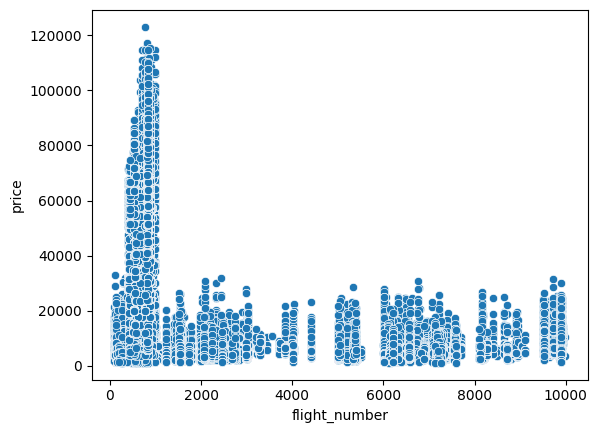

In [73]:
# Fight numberと相関関係があるのかScatter plotで確認
sns.scatterplot(x='flight_number', y='price', data=df)

<Axes: xlabel='flight_number', ylabel='price'>

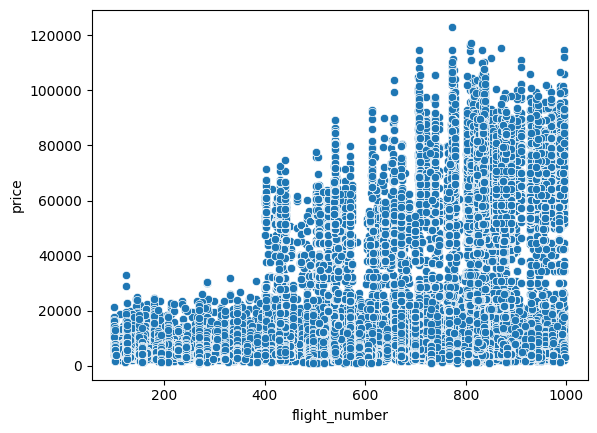

In [74]:
# Flight numberが1000未満のデータのみで確認
sns.scatterplot(x='flight_number', y='price', data=df[df['flight_number'] < 1000])

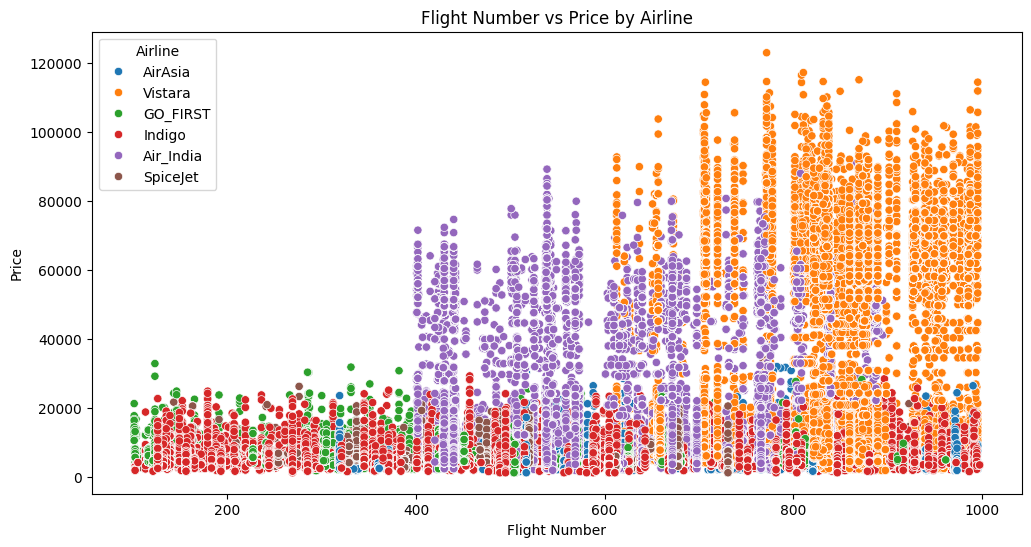

In [75]:
# AirlineごとにFlight numberとPriceの関係を確認
plt.figure(figsize=(12, 6))
sns.scatterplot(x='flight_number', y='price', hue='airline', data=df[df['flight_number'] < 1000])
plt.title('Flight Number vs Price by Airline')
plt.xlabel('Flight Number')
plt.ylabel('Price')
plt.legend(title='Airline')
plt.show()

In [76]:
# 相関があるようには見えないので、flight, flight_number, flight_codeは削除する
df.drop(['flight', 'flight_number', 'flight_code'], axis=1, inplace=True)
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [77]:
# cat_featuresからも削除
cat_features.remove('flight')
cat_features.remove('flight_code')
cat_features.remove('flight_number')
cat_features

['airline',
 'source_city',
 'departure_time',
 'stops',
 'arrival_time',
 'destination_city',
 'class']

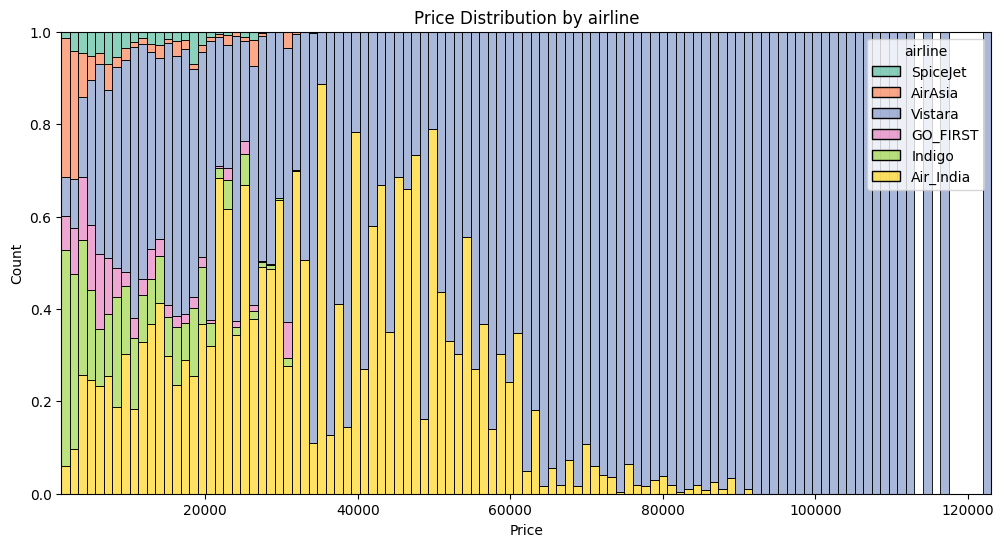

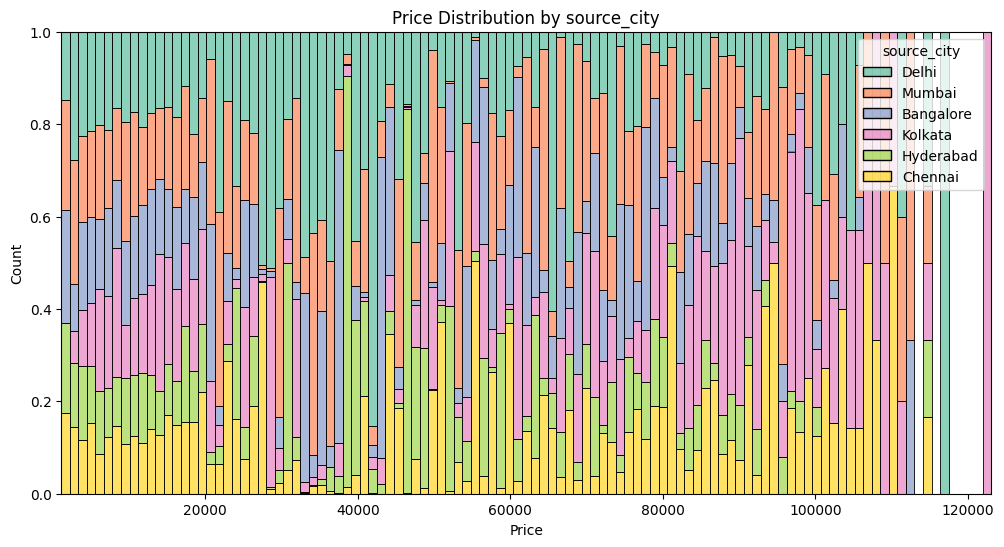

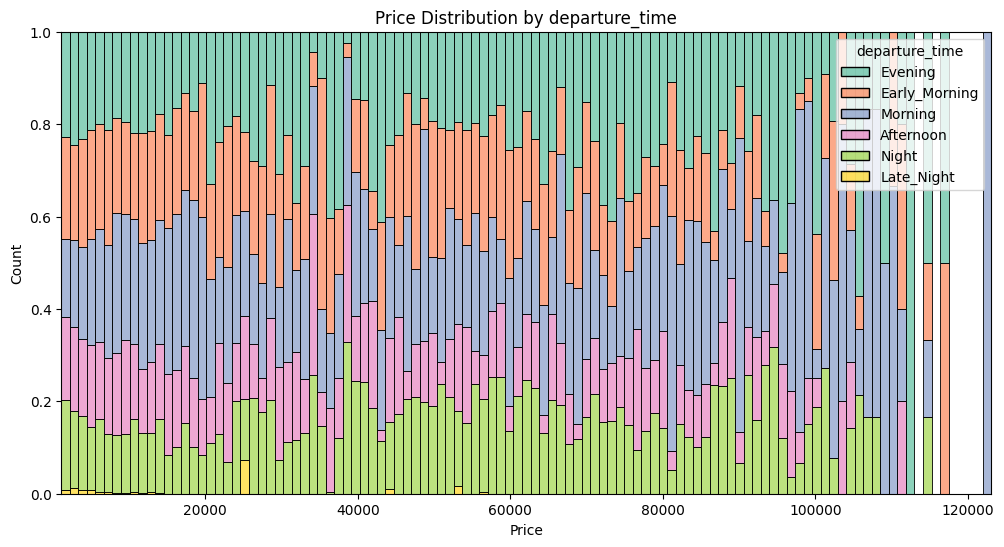

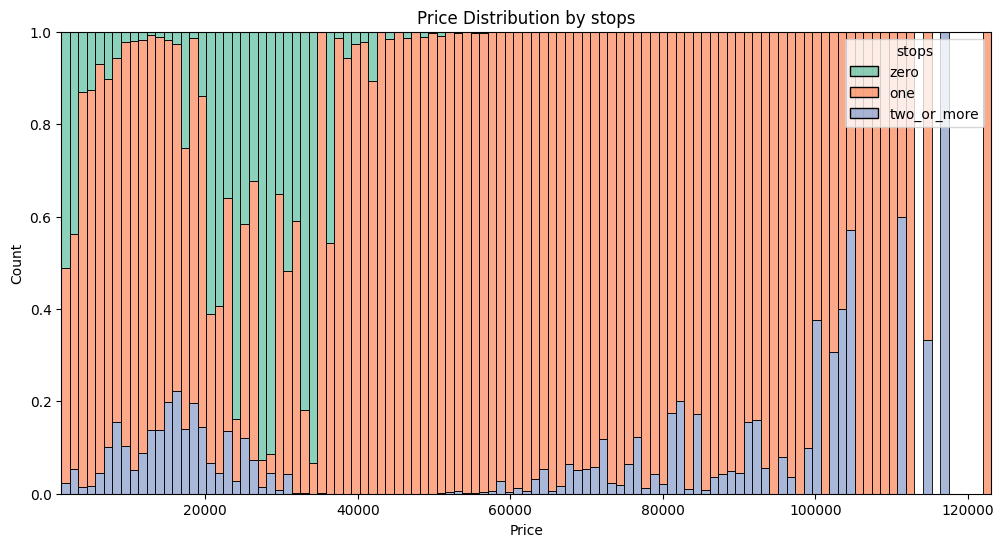

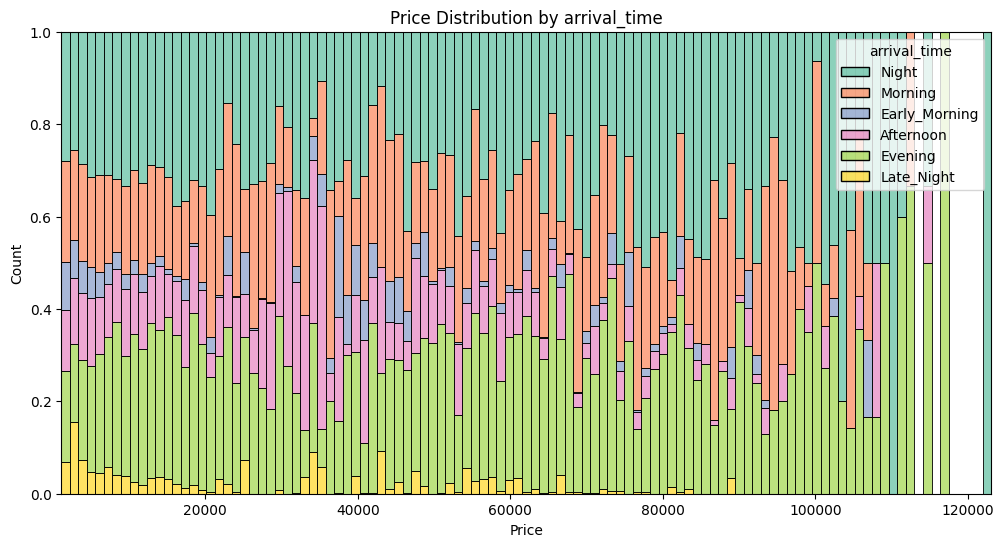

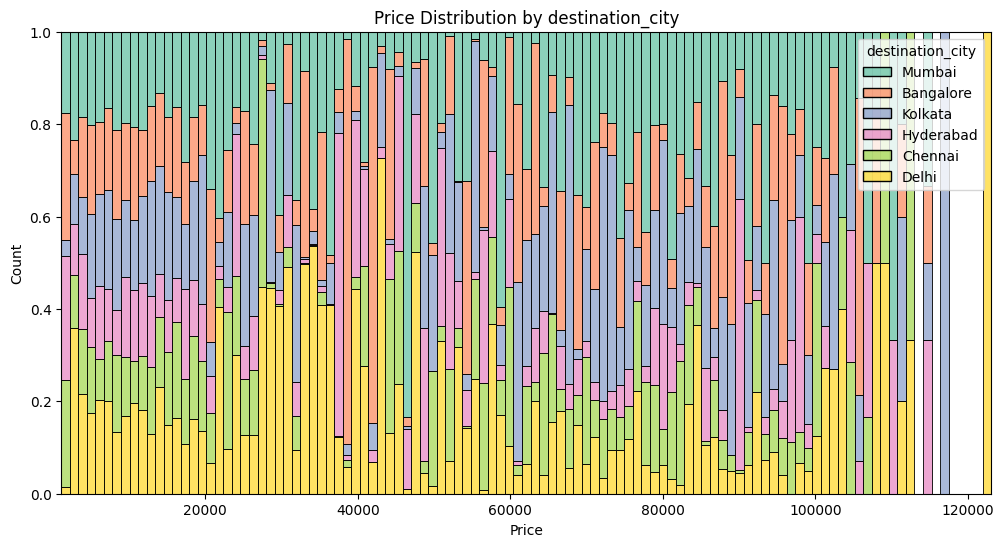

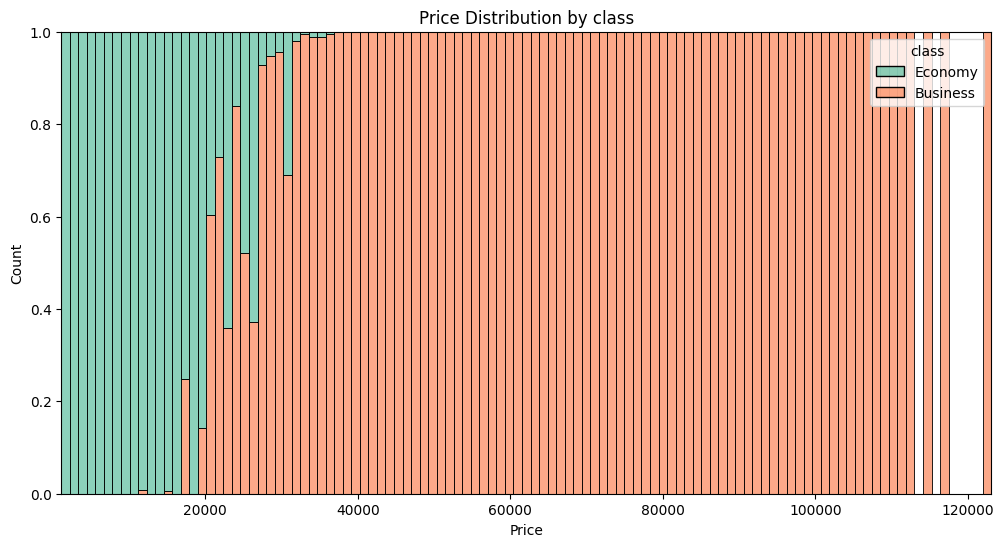

In [78]:
# priceとcat_featuresの関係をそれぞれヒストグラムでfor文で,Airlineごとに色分けして表示する
for feature in cat_features:
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(data=df, x='price', hue=feature, multiple='fill', palette='Set2')
    plt.title(f'Price Distribution by {feature}')
    plt.xlabel('Price')
    plt.ylabel('Count')
    sns.move_legend(ax, 'upper right', title=feature)
    plt.show()
# airlineによって価格帯が異なるように見える（AirAsia, IndiGo, 高価格帯までカバーしてるのはVistara）
# source_city、Departure_timeは価格帯に影響がないように見える


In [79]:
# num_featuresとpriceの相関係数を確認
df[num_features + ['price']].corr()


,duration,days_left,price
duration,1.000000,-0.039157,0.204222
days_left,-0.039157,1.000000,-0.091949
price,0.204222,-0.091949,1.000000


In [80]:
# ライブラリーのインポート、RandomForestRegressorを使用する
from re import X

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error # 評価の指標
from sklearn.preprocessing import OneHotEncoder

# 目的変数と説明変数の分割
df_y = df.pop('price') # 目的変数をdf_yに格納し、dfからは削除
df_X = df # 説明変数をdf_Xに格納

# データの分割
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=17)



In [81]:
# 念の為データの形状を確認
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((240122, 9), (60031, 9), (240122,), (60031,))

In [82]:
encoder = OneHotEncoder(drop='first') # drop='first'は、最初のカテゴリを削除して、ダミー変数の多重共線性を防ぐためのオプション
X_train_cat_array = encoder.fit_transform(X_train[cat_features]) # 学習データのColor列とShape列のユニークな値を学習させる
X_test_cat_array = encoder.transform(X_test[cat_features]) # 学習データのColor列とShape列のユニークな値を使って、テストデータのColor列とShape列を変換する
X_train_cat_array[:3].toarray()

array([[0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.]])

In [84]:
X_train_num_array = X_train[num_features].values
X_test_num_array = X_test[num_features].values

In [85]:
X_train = np.concatenate([X_train_cat_array.toarray(), X_train_num_array], axis=1)
X_test = np.concatenate([X_test_cat_array.toarray(), X_test_num_array], axis=1)
X_train.shape, X_test.shape


((240122, 30), (60031, 30))

In [86]:
rf_model = RandomForestRegressor(random_state=17)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=17)